# Task 3: Customer Churn Prediction (Bank Customers)

## Introduction
Customer churn refers to customers leaving the bank or discontinuing its services. Predicting churn is important because it helps banks identify at-risk customers and take proactive steps to retain them.

## Objective
The objective of this task is to build a classification model that predicts whether a customer is likely to leave the bank. This includes cleaning the dataset, encoding categorical features such as geography and gender, and analyzing which factors influence customer churn.

## Dataset
The Churn Modelling Dataset contains customer-related information such as age, gender, geography, account balance, and activity status. The target variable indicates whether the customer has exited the bank or not.

In [ ]:
import pandas as pd
#import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)
 
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [2]:
df = pd.read_csv("Churn.csv")
 
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (10000, 14)

Columns: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
print("Data Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Data Types:
 RowNumber            int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Missing Values:
 RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Basic Statistics:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [4]:
# Drop columns that carry no predictive value
df.drop(columns=["RowNumber", "CustomerId", "Surname"], inplace=True)
 
# --- Label Encoding: Gender (binary) ---
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])  # Female=0, Male=1
 
# --- One-Hot Encoding: Geography (3 categories) ---
df = pd.get_dummies(df, columns=["Geography"], drop_first=True)
# drop_first avoids multicollinearity (dummy variable trap)
 
print("Shape after encoding:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape after encoding: (10000, 12)
Columns: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


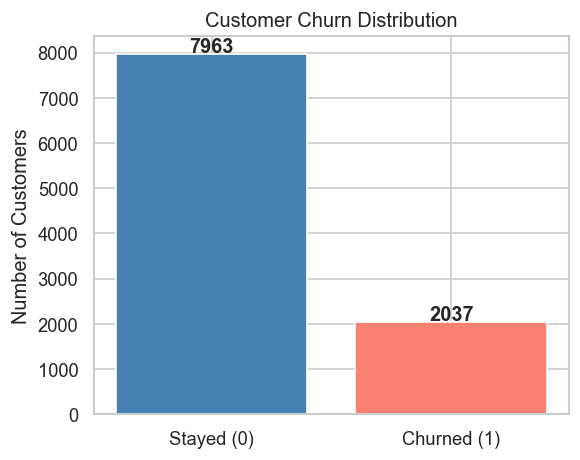

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["Exited"].value_counts()
ax.bar(["Stayed (0)", "Churned (1)"], counts.values, color=["steelblue", "salmon"])
ax.set_title("Customer Churn Distribution")
ax.set_ylabel("Number of Customers")
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("churn_distribution.png")
plt.show()
 

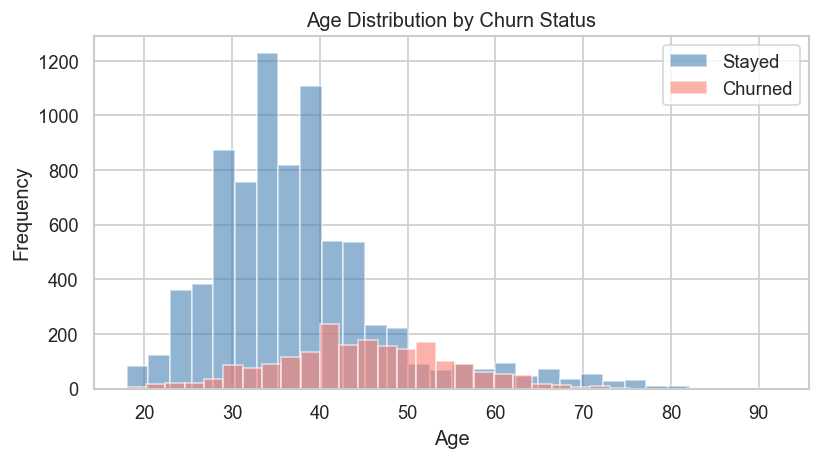

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
df[df["Exited"] == 0]["Age"].plot(kind="hist", bins=30, alpha=0.6,
                                   label="Stayed", color="steelblue", ax=ax)
df[df["Exited"] == 1]["Age"].plot(kind="hist", bins=30, alpha=0.6,
                                   label="Churned", color="salmon", ax=ax)
ax.set_title("Age Distribution by Churn Status")
ax.set_xlabel("Age")
ax.legend()
plt.tight_layout()
plt.savefig("age_by_churn.png")
plt.show()

/var/folders/jm/s2f0ymjs3vx9jm3b2n6ytj4c0000gn/T/ipykernel_70695/1996309407.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Stayed", "Churned"])


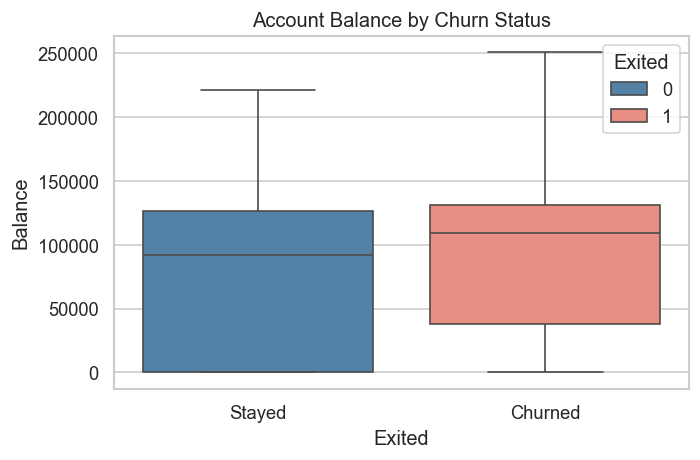

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x="Exited", y="Balance",hue="Exited", data=df, palette=["steelblue", "salmon"], ax=ax)
ax.set_xticklabels(["Stayed", "Churned"])
ax.set_title("Account Balance by Churn Status")
plt.tight_layout()
plt.savefig("balance_by_churn.png")
plt.show()

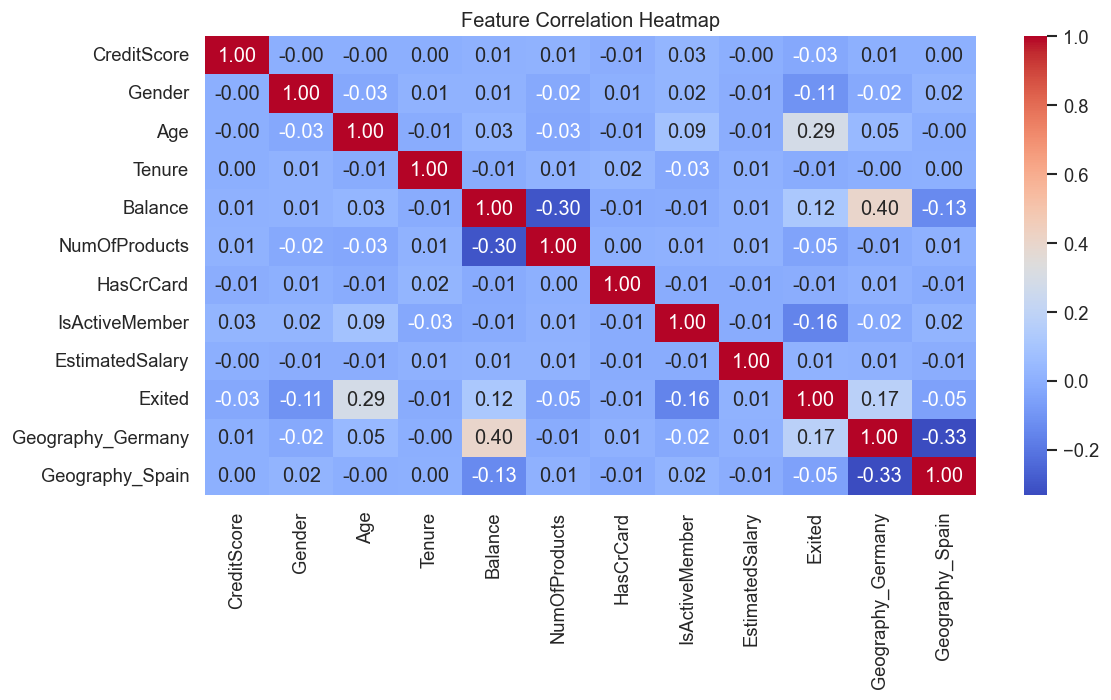

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()

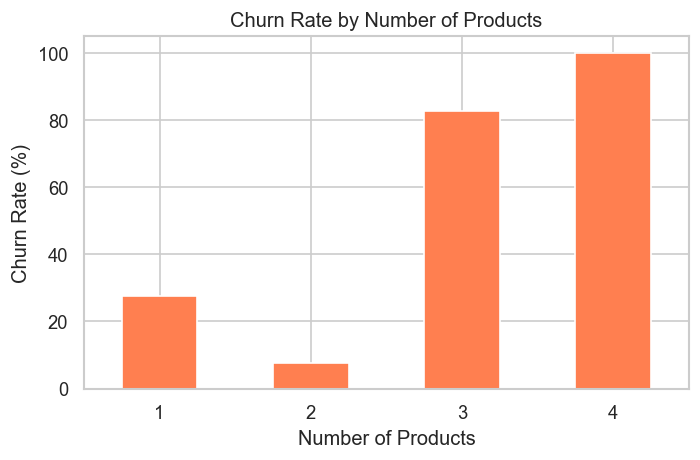

In [20]:
fig, ax = plt.subplots(figsize=(6, 4))
churn_by_product = df.groupby("NumOfProducts")["Exited"].mean() * 100
churn_by_product.plot(kind="bar", color="coral", ax=ax)
ax.set_title("Churn Rate by Number of Products")
ax.set_xlabel("Number of Products")
ax.set_ylabel("Churn Rate (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig("churn_by_products.png")
plt.show()

In [21]:
# --- Split features and target ---
X = df.drop(columns=["Exited"])
y = df["Exited"]
 
# --- Train/Test Split (80/20) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
 
# %%
# --- Feature Scaling (important for some models) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
 
# %%
# --- Train Random Forest Classifier ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
 
# Predict
y_pred = rf_model.predict(X_test_scaled)

Training samples: 8000
Testing samples:  2000


Model Accuracy: 86.15%

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.87      0.97      0.92      1593
     Churned       0.77      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000



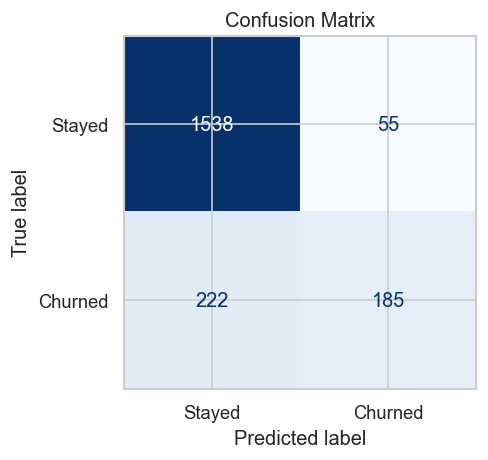

In [22]:
# --- Accuracy ---
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")
 
# %%
# --- Classification Report ---
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Stayed", "Churned"]))
 
# %%
# --- Confusion Matrix ---
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Stayed", "Churned"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()
 

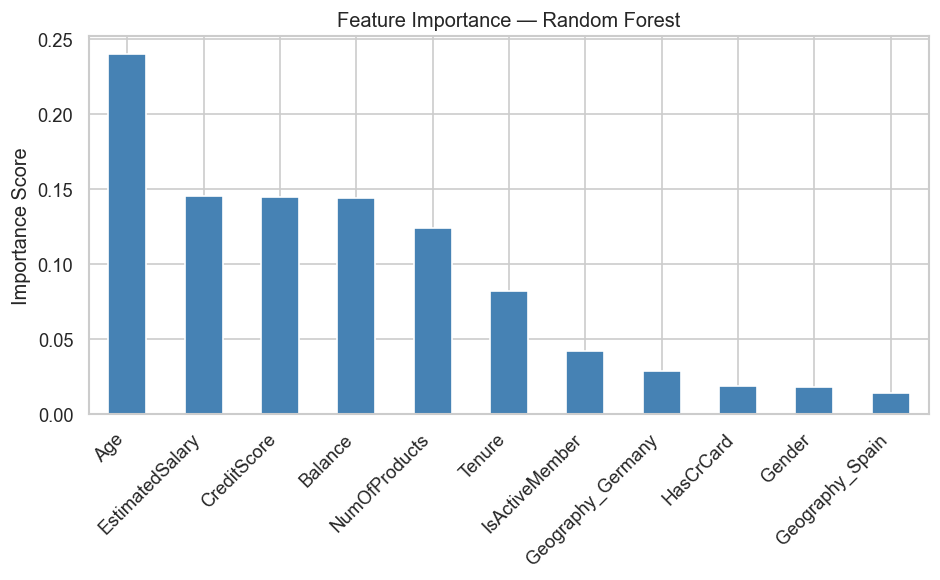


Top 5 most important features:
Age                0.239730
EstimatedSalary    0.144951
CreditScore        0.144612
Balance            0.143798
NumOfProducts      0.123917
dtype: float64


In [23]:
# ## 8. Feature Importance Analysis
 
feature_importance = pd.Series(
    rf_model.feature_importances_, index=X.columns
).sort_values(ascending=False)
 
fig, ax = plt.subplots(figsize=(8, 5))
feature_importance.plot(kind="bar", color="steelblue", ax=ax)
ax.set_title("Feature Importance — Random Forest")
ax.set_ylabel("Importance Score")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()
 
print("\nTop 5 most important features:")
print(feature_importance.head())

## Conclusion

- The Random Forest model achieved a solid accuracy on the test set.
- **Age** is the most influential feature — older customers churn more.
- **Number of Products** also strongly impacts churn; customers with only 1 product or more than 2 products show higher churn rates.
- **Account Balance** is higher among churned customers, suggesting that even high-value customers leave if not engaged properly.
- **Geography** (Germany specifically) has a notably higher churn rate.
- Banks should focus retention efforts on older, single-product customers in Germany.
 